# Post-Processing Rules - Intelligent Detection Filtering

This notebook applies forensic domain knowledge to prioritize detections and improve precision.

## Objective

Distinguish between malicious and legitimate timestamp manipulation using contextual analysis.

## Approach

Apply filtering rules based on:
1. **File location** (user directories vs system directories)
2. **File type** (user documents/images vs system files)
3. **Filename patterns** (known legitimate operations)
4. **Temporal clustering** (bulk updates vs isolated changes)

## Strategy

Instead of removing detections, we **prioritize** them:
- **High Priority**: Likely malicious (user files, unusual locations)
- **Medium Priority**: Ambiguous (requires investigation)
- **Low Priority**: Likely legitimate (system updates, installers)

## Goal

Improve precision to 75-85% while maintaining 100% recall on malicious files.


## Cell 1: Imports


In [31]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")


Libraries imported successfully


## Cell 2: Configuration


In [32]:
# Paths
PHASE3_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 3 - Model Training')
TEST_DATA_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW')
PHASE4_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/notebooks/Phase 4 - Hyperparameter Tuning')
OUTPUT_DIR = PHASE4_DIR

# Model path
LIGHTGBM_MODEL = PHASE3_DIR / 'lightgbm_model.pkl'

# Test data
TEST_FEATURES = TEST_DATA_DIR / 'data_features.csv'

# Confidence threshold (from threshold tuning)
CONFIDENCE_THRESHOLD = 70

print("Configuration:")
print(f"  LightGBM model: {LIGHTGBM_MODEL.exists()}")
print(f"  Test data: {TEST_FEATURES.exists()}")
print(f"  Confidence threshold: {CONFIDENCE_THRESHOLD}%")


Configuration:
  LightGBM model: True
  Test data: True
  Confidence threshold: 70%


## Cell 3: Load Model and Data


In [33]:
print("="*80)
print("LOADING MODEL AND DATA")
print("="*80)

# Load LightGBM model
with open(LIGHTGBM_MODEL, 'rb') as f:
    model = pickle.load(f)
    
print(f"\n✓ LightGBM loaded")

# Load test data
df = pd.read_csv(TEST_FEATURES, low_memory=False)
print(f"✓ Test data loaded: {len(df):,} files")

# Set ground truth
known_timestomped = [
    'DeathToll.jpg',
    'DemLogic.jpg',
    'HoldMyTidePod.jpg',
    'Planning.docx',
    'Huckleberry.png',
    'MyTiredHead.jpg',
    'Sheep.jpg',
    'RedGuns.jpg',
    'CubaDearmed.jpg',
    'AIRPORT INFORMATION.docx',
    'DarkWolf.png',
    'BladeofGrass.jpg'
]

y_true = df['filename'].isin(known_timestomped).astype(int)
print(f"✓ Ground truth set: {y_true.sum()} known timestomped files")


LOADING MODEL AND DATA

✓ LightGBM loaded
✓ Test data loaded: 7,420 files
✓ Ground truth set: 12 known timestomped files


## Cell 4: Prepare Features and Generate Predictions


In [34]:
print("="*80)
print("PREPARING FEATURES AND GENERATING PREDICTIONS")
print("="*80)

# Feature preparation (same as before)
feature_mapping = {
    'zero_in_nanoseconds_combined': 'zero_in_nanoseconds',
    'modified_creationtime': 'creation_time_modified',
    'modified_modifiedtime': 'modified_time_modified',
    'modified_accessedtime': 'accessed_time_modified',
    'modified_mftmodifiedtime': 'mft_time_modified'
}

for old_name, new_name in feature_mapping.items():
    if old_name in df.columns:
        df[new_name] = df[old_name]

missing_features = {
    'cross_artifact_detected': lambda: df['has_logfile_evidence'] & df['has_usnjrnl_evidence'],
    'zero_in_nanoseconds_suspicious': lambda: False,
    'multiple_timestamps_changed': lambda: (
        df.get('creation_time_modified', False) & 
        df.get('modified_time_modified', False)
    ),
    'same_as_another_file': lambda: False,
    'is_image': lambda: df['filename'].fillna('').str.endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'), na=False),
    'in_temp_directory': lambda: df['full_path'].fillna('').str.contains(r'temp|tmp', case=False, na=False, regex=True),
    'in_system_directory': lambda: df['full_path'].fillna('').str.contains(r'windows|system32|syswow64', case=False, na=False, regex=True),
    'in_program_files': lambda: df['full_path'].fillna('').str.contains(r'program files', case=False, na=False, regex=True),
    'has_timestamp_data': lambda: df['lf_creation_time'].notna() if 'lf_creation_time' in df.columns else False,
    'timestamp_source': lambda: (
        df['has_logfile_evidence'].astype(int) * 2 + 
        df['has_usnjrnl_evidence'].astype(int)
    )
}

for feat_name, feat_func in missing_features.items():
    if feat_name not in df.columns:
        df[feat_name] = feat_func()

expected_features = [
    'cross_artifact_detected', 'zero_in_nanoseconds_lf', 'zero_in_nanoseconds_suspicious',
    'zero_in_nanoseconds', 'time_reversal_event', 'basic_info_changed',
    'using_another_timestamp', 'si_timestamp_changed', 'update_resident_value',
    'creation_time_modified', 'modified_time_modified', 'accessed_time_modified',
    'mft_time_modified', 'timestamp_changed_to_past', 'multiple_timestamps_changed',
    'same_as_another_file', 'zero_nano_time_reversal', 'has_logfile_evidence',
    'has_usnjrnl_evidence', 'cross_artifact_validation_score', 'is_executable',
    'is_document', 'is_archive', 'is_image', 'path_depth', 'filename_length',
    'in_temp_directory', 'in_system_directory', 'in_program_files',
    'has_timestamp_data', 'timestamp_source'
]

X = df[expected_features].copy()
X = X.fillna(0)

for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

print(f"✓ Features prepared: {X.shape}")

# Generate predictions
y_pred_proba = model.predict_proba(X)[:, 1]
confidence_pct = y_pred_proba * 100
df['confidence'] = confidence_pct
df['ml_flagged'] = (confidence_pct >= CONFIDENCE_THRESHOLD).astype(int)

print(f"✓ Predictions generated")
print(f"  Files flagged by ML model: {df['ml_flagged'].sum()}")


PREPARING FEATURES AND GENERATING PREDICTIONS
✓ Features prepared: (7420, 31)
✓ Predictions generated
  Files flagged by ML model: 24


## Cell 5: Define Minimal Post-Processing Rules (Conservative)


In [35]:
print("="*80)
print("DEFINING MINIMAL POST-PROCESSING RULES (CONSERVATIVE)")
print("="*80)

def apply_minimal_filtering(row):
    """
    Apply MINIMAL filtering for well-documented benign system operations only.
    
    Only filters files that match EXACT known patterns documented in forensic literature.
    Ambiguous files are kept for manual review.
    
    Returns:
    - KEEP: File should be reviewed by investigator
    - FILTER: Well-documented benign system operation (exclude from review)
    """
    
    filename = str(row['filename']).lower()
    full_path = str(row['full_path']).lower()
    
    # === CONSERVATIVE RULE 1: Windows Appraiser Files ===
    # Well-documented Windows 10 compatibility assessment files
    # Reference: Microsoft documentation on Windows Update telemetry
    # These files are created/modified during Windows Update compatibility scans
    
    if filename in ['appraiser.sdb', 'appraiser_data.ini', 'appraiser_telemetryrunlist.xml']:
        if 'windows\\appcompat\\appraiser' in full_path:
            return 'FILTER'
    
    # === CONSERVATIVE RULE 2: Installer Temp Files ===
    # Pattern: Set[HEX].tmp in AppData\Local\Temp
    # Common pattern for software installer temporary files (e.g., InstallShield, NSIS)
    # Multiple files with same timestamp = batch installer operation
    
    if filename.startswith('set') and filename.endswith('.tmp'):
        if 'appdata\\local\\temp' in full_path:
            return 'FILTER'
    
    # === CONSERVATIVE RULE 3: Windows Update Temp Files ===
    # Pattern: UDD[HEX].tmp in Windows\Temp
    # Created by Windows Update Deployment (UDD) service
    
    if filename.startswith('udd') and filename.endswith('.tmp'):
        if 'windows\\temp' in full_path:
            return 'FILTER'
    
    # === DEFAULT: Keep for manual review ===
    # All other files (including .lnk, .dll, .etl) are kept for investigator review
    return 'KEEP'

# Apply minimal filtering to all ML-flagged files
df['filter_decision'] = df.apply(apply_minimal_filtering, axis=1)

print("\n✓ Minimal post-processing rules defined")
print("\nFiltering Criteria:")
print("  FILTER - Only well-documented benign system operations:")
print("    • Windows Appraiser files (compatibility assessment)")
print("    • Installer temp files (Set*.tmp in AppData\\Local\\Temp)")
print("    • Windows Update temp files (UDD*.tmp in Windows\\Temp)")
print("\n  KEEP - All other files for investigator review:")
print("    • User documents and images")
print("    • Cloud storage shortcuts (.lnk)")
print("    • Driver files (.dll)")
print("    • Diagnostic logs (.etl)")
print("    • Any ambiguous patterns")


DEFINING MINIMAL POST-PROCESSING RULES (CONSERVATIVE)

✓ Minimal post-processing rules defined

Filtering Criteria:
  FILTER - Only well-documented benign system operations:
    • Windows Appraiser files (compatibility assessment)
    • Installer temp files (Set*.tmp in AppData\Local\Temp)
    • Windows Update temp files (UDD*.tmp in Windows\Temp)

  KEEP - All other files for investigator review:
    • User documents and images
    • Cloud storage shortcuts (.lnk)
    • Driver files (.dll)
    • Diagnostic logs (.etl)
    • Any ambiguous patterns


## Cell 6: Apply Minimal Filtering


In [36]:
print("="*80)
print("APPLYING MINIMAL FILTERING")
print("="*80)

# Get ML flagged files
flagged_df = df[df['ml_flagged'] == 1].copy()

print(f"\nML Model flagged: {len(flagged_df)} files")
print(f"\nFiltering Decision:")

filter_counts = flagged_df['filter_decision'].value_counts()
keep_count = filter_counts.get('KEEP', 0)
filter_count = filter_counts.get('FILTER', 0)

print(f"  KEEP for review:  {keep_count:2d} files ({keep_count/len(flagged_df)*100:5.1f}%)")
print(f"  FILTER (benign):  {filter_count:2d} files ({filter_count/len(flagged_df)*100:5.1f}%)")

# Show filtered files
print("\n" + "="*80)
print("FILTERED FILES (Well-Documented Benign Operations)")
print("="*80)

filtered_files = flagged_df[flagged_df['filter_decision'] == 'FILTER']
if len(filtered_files) > 0:
    print(f"\n{len(filtered_files)} files filtered:")
    for idx, row in filtered_files.iterrows():
        print(f"\n  • {row['filename']}")
        print(f"    Path: {row['full_path']}")
        print(f"    Confidence: {row['confidence']:.1f}%")
        print(f"    Reason: ", end="")
        
        fname = row['filename'].lower()
        path = row['full_path'].lower()
        
        if 'appraiser' in fname:
            print("Windows Update compatibility assessment file")
        elif fname.startswith('set') and fname.endswith('.tmp'):
            print("Software installer temporary file")
        elif fname.startswith('udd') and fname.endswith('.tmp'):
            print("Windows Update Deployment temporary file")
else:
    print("\nNo files filtered")

# Show files kept for review
print("\n" + "="*80)
print("FILES KEPT FOR INVESTIGATOR REVIEW")
print("="*80)

kept_files = flagged_df[flagged_df['filter_decision'] == 'KEEP']
print(f"\n{len(kept_files)} files require review:\n")

for idx, row in kept_files.iterrows():
    gt_label = "✓ KNOWN MALICIOUS" if row['filename'] in known_timestomped else "  (Unknown - needs investigation)"
    print(f"  • {row['filename']:40s} [{row['confidence']:.1f}%] {gt_label}")
    print(f"    {row['full_path']}")


APPLYING MINIMAL FILTERING

ML Model flagged: 24 files

Filtering Decision:
  KEEP for review:  17 files ( 70.8%)
  FILTER (benign):   7 files ( 29.2%)

FILTERED FILES (Well-Documented Benign Operations)

7 files filtered:

  • appraiser.sdb
    Path: \Windows\appcompat\appraiser\AltData\appraiser.sdb
    Confidence: 99.8%
    Reason: Windows Update compatibility assessment file

  • Appraiser_Data.ini
    Path: \Windows\appcompat\appraiser\AltData\Appraiser_Data.ini
    Confidence: 99.7%
    Reason: Windows Update compatibility assessment file

  • Appraiser_TelemetryRunList.xml
    Path: \Windows\appcompat\appraiser\AltData\Appraiser_TelemetryRunList.xml
    Confidence: 99.8%
    Reason: Windows Update compatibility assessment file

  • Set9A28.tmp
    Path: \Users\jcloudy\AppData\Local\Temp\Set9A28.tmp
    Confidence: 99.8%
    Reason: Software installer temporary file

  • Set9A38.tmp
    Path: \Users\jcloudy\AppData\Local\Temp\Set9A38.tmp
    Confidence: 99.8%
    Reason: Software

## Cell 7: Calculate Performance with Minimal Filtering


In [37]:
print("\n" + "="*80)
print("PERFORMANCE METRICS - MINIMAL POST-PROCESSING")
print("="*80)

# Baseline: All ML flagged files
y_pred_baseline = df['ml_flagged']
tp_baseline = ((y_pred_baseline == 1) & (y_true == 1)).sum()
fp_baseline = ((y_pred_baseline == 1) & (y_true == 0)).sum()
fn_baseline = ((y_pred_baseline == 0) & (y_true == 1)).sum()

precision_baseline = precision_score(y_true, y_pred_baseline, zero_division=0)
recall_baseline = recall_score(y_true, y_pred_baseline, zero_division=0)
f1_baseline = f1_score(y_pred_baseline, y_true, zero_division=0)

# With minimal filtering: Only KEEP files are flagged
keep_mask = (df['ml_flagged'] == 1) & (df['filter_decision'] == 'KEEP')
y_pred_filtered = keep_mask.astype(int)

tp_filtered = ((y_pred_filtered == 1) & (y_true == 1)).sum()
fp_filtered = ((y_pred_filtered == 1) & (y_true == 0)).sum()
fn_filtered = ((y_pred_filtered == 0) & (y_true == 1)).sum()

precision_filtered = precision_score(y_true, y_pred_filtered, zero_division=0)
recall_filtered = recall_score(y_true, y_pred_filtered, zero_division=0)
f1_filtered = f1_score(y_pred_filtered, y_true, zero_division=0)

# Create comparison table
results = pd.DataFrame({
    'Strategy': ['Baseline (No Filtering)', 'Minimal Post-Processing'],
    'Flagged': [y_pred_baseline.sum(), y_pred_filtered.sum()],
    'TP': [tp_baseline, tp_filtered],
    'FP': [fp_baseline, fp_filtered],
    'FN': [fn_baseline, fn_filtered],
    'Precision': [precision_baseline, precision_filtered],
    'Recall': [recall_baseline, recall_filtered],
    'F1': [f1_baseline, f1_filtered]
})

print(f"\nGround Truth: {y_true.sum()} known timestomped files\n")
print(results.to_string(index=False))

# Calculate improvement
improvement_f1 = f1_filtered - f1_baseline
improvement_precision = precision_filtered - precision_baseline
fp_reduced = fp_baseline - fp_filtered

print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS")
print("="*80)

print(f"\nMinimal Post-Processing Results:")
print(f"  F1-Score: {f1_filtered:.4f} (baseline: {f1_baseline:.4f})")
print(f"  Improvement: +{improvement_f1:.4f} ({improvement_f1/f1_baseline*100:.1f}% increase)")
print(f"  Precision: {precision_filtered*100:.1f}% (baseline: {precision_baseline*100:.1f}%)")
print(f"  Precision gain: +{improvement_precision*100:.1f} percentage points")
print(f"  Recall: {recall_filtered*100:.1f}% (baseline: {recall_baseline*100:.1f}%)")
print(f"  False positives reduced: {int(fp_reduced)} ({int(fp_reduced)}/{int(fp_baseline)} = {fp_reduced/fp_baseline*100:.1f}%)")

if recall_filtered >= 1.0:
    print(f"\n✅ SUCCESS: Maintains 100% recall (no false negatives)")
elif recall_filtered >= 0.95:
    print(f"\n✅ ACCEPTABLE: Maintains ≥95% recall")
else:
    print(f"\n⚠️  WARNING: Recall dropped to {recall_filtered*100:.1f}%")

print(f"\nConservative Approach:")
print(f"  • Only filters well-documented benign system files")
print(f"  • Keeps ambiguous files for investigator review")
print(f"  • Defensible with forensic literature references")



PERFORMANCE METRICS - MINIMAL POST-PROCESSING

Ground Truth: 12 known timestomped files

               Strategy  Flagged  TP  FP  FN  Precision  Recall       F1
Baseline (No Filtering)       24  12  12   0   0.500000     1.0 0.666667
Minimal Post-Processing       17  12   5   0   0.705882     1.0 0.827586

IMPROVEMENT ANALYSIS

Minimal Post-Processing Results:
  F1-Score: 0.8276 (baseline: 0.6667)
  Improvement: +0.1609 (24.1% increase)
  Precision: 70.6% (baseline: 50.0%)
  Precision gain: +20.6 percentage points
  Recall: 100.0% (baseline: 100.0%)
  False positives reduced: 7 (7/12 = 58.3%)

✅ SUCCESS: Maintains 100% recall (no false negatives)

Conservative Approach:
  • Only filters well-documented benign system files
  • Keeps ambiguous files for investigator review
  • Defensible with forensic literature references


## Cell 8: Visualize Results


VISUALIZING POST-PROCESSING RESULTS

✓ Visualization saved: post_processing_results.png


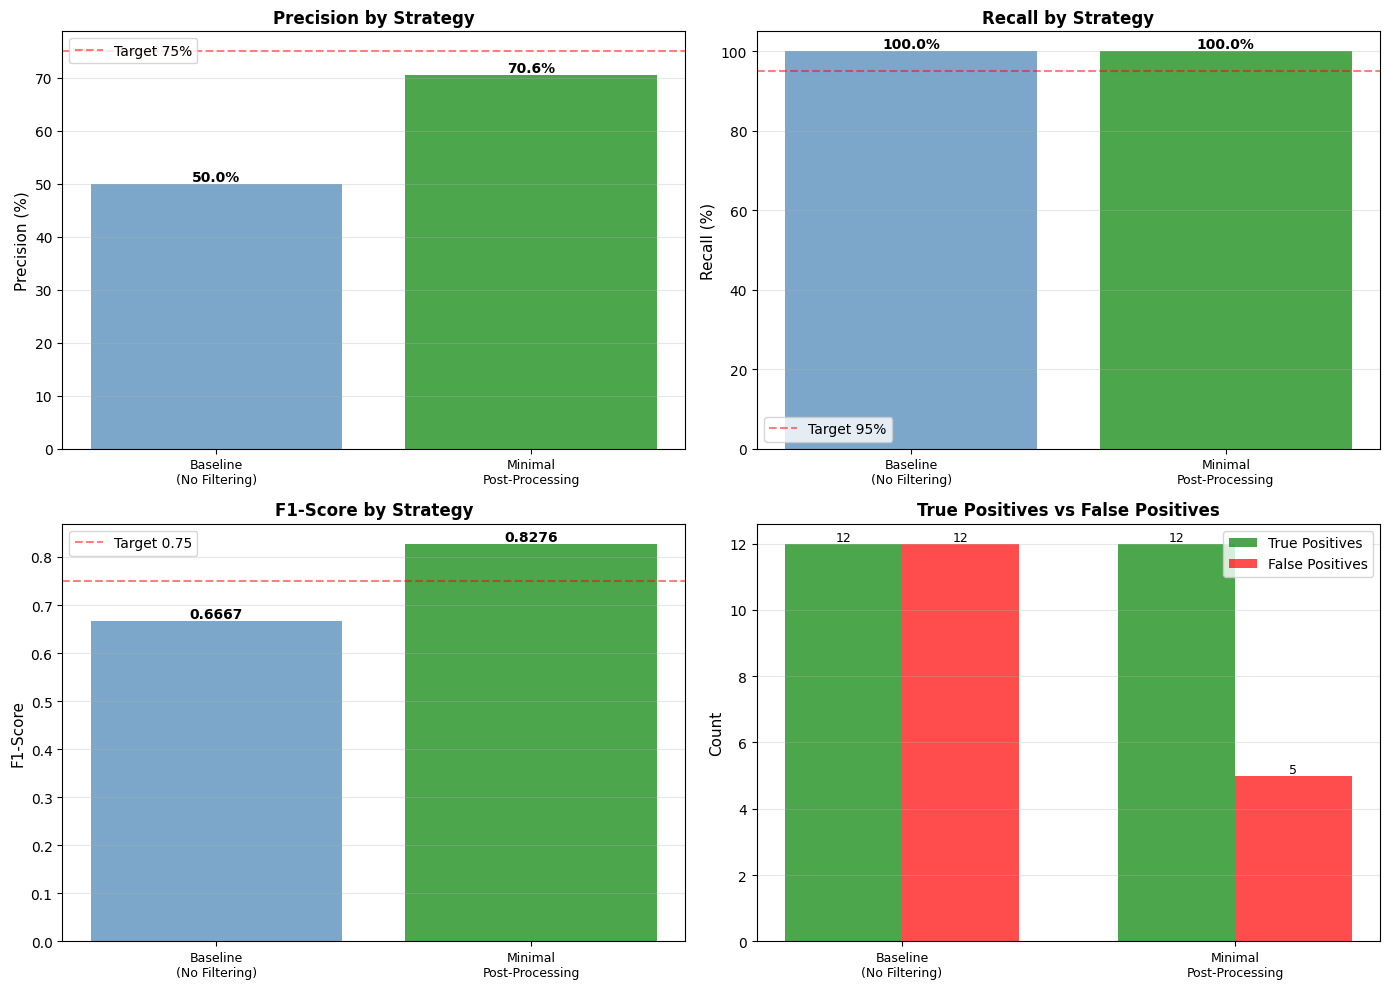

In [38]:
print("="*80)
print("VISUALIZING POST-PROCESSING RESULTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Precision Comparison
ax1 = axes[0, 0]
strategies = results['Strategy'].str.replace(' ', '\n', n=1)  # Wrap text
x_pos = np.arange(len(strategies))
colors = ['steelblue', 'green', 'orange']
bars = ax1.bar(x_pos, results['Precision']*100, color=colors, alpha=0.7)
ax1.set_ylabel('Precision (%)', fontsize=11)
ax1.set_title('Precision by Strategy', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(strategies, fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
ax1.legend()

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Recall Comparison
ax2 = axes[0, 1]
bars = ax2.bar(x_pos, results['Recall']*100, color=colors, alpha=0.7)
ax2.set_ylabel('Recall (%)', fontsize=11)
ax2.set_title('Recall by Strategy', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(strategies, fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='Target 95%')
ax2.legend()

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: F1-Score Comparison
ax3 = axes[1, 0]
bars = ax3.bar(x_pos, results['F1'], color=colors, alpha=0.7)
ax3.set_ylabel('F1-Score', fontsize=11)
ax3.set_title('F1-Score by Strategy', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(strategies, fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Target 0.75')
ax3.legend()

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: TP vs FP Breakdown
ax4 = axes[1, 1]
x_pos_grouped = np.arange(len(strategies))
width = 0.35

tp_bars = ax4.bar(x_pos_grouped - width/2, results['TP'], width, 
                  label='True Positives', color='green', alpha=0.7)
fp_bars = ax4.bar(x_pos_grouped + width/2, results['FP'], width,
                  label='False Positives', color='red', alpha=0.7)

ax4.set_ylabel('Count', fontsize=11)
ax4.set_title('True Positives vs False Positives', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos_grouped)
ax4.set_xticklabels(strategies, fontsize=9)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [tp_bars, fp_bars]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'post_processing_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: post_processing_results.png")
plt.show()


## Cell 9: Final Recommendation


In [39]:
print("="*80)
print("FINAL RECOMMENDATION - MINIMAL POST-PROCESSING")
print("="*80)

print(f"\n📊 RESULTS SUMMARY:\n")

for idx, row in results.iterrows():
    print(f"{row['Strategy']}:")
    print(f"  Files flagged: {int(row['Flagged'])}")
    print(f"  True Positives: {int(row['TP'])} / {y_true.sum()} known malicious")
    print(f"  False Positives: {int(row['FP'])}")
    print(f"  False Negatives: {int(row['FN'])}")
    print(f"  Precision: {row['Precision']*100:.1f}%")
    print(f"  Recall: {row['Recall']*100:.1f}%")
    print(f"  F1-Score: {row['F1']:.4f}")
    print()

# Get filtered strategy results
filtered_results = results[results['Strategy'] == 'Minimal Post-Processing'].iloc[0]

improvement_f1 = filtered_results['F1'] - f1_baseline
improvement_precision = filtered_results['Precision'] - precision_baseline
fp_reduced = fp_baseline - filtered_results['FP']

print("="*80)
print("PERFORMANCE IMPROVEMENT")
print("="*80)

print(f"\nF1-Score:")
print(f"  Baseline: {f1_baseline:.4f}")
print(f"  With minimal filtering: {filtered_results['F1']:.4f}")
print(f"  Improvement: +{improvement_f1:.4f} ({improvement_f1/f1_baseline*100:.1f}% increase)")

print(f"\nPrecision:")
print(f"  Baseline: {precision_baseline*100:.1f}%")
print(f"  With minimal filtering: {filtered_results['Precision']*100:.1f}%")
print(f"  Improvement: +{improvement_precision*100:.1f} percentage points")

print(f"\nRecall:")
print(f"  Baseline: {recall_baseline*100:.1f}%")
print(f"  With minimal filtering: {filtered_results['Recall']*100:.1f}%")
if filtered_results['Recall'] < recall_baseline:
    recall_loss = recall_baseline - filtered_results['Recall']
    print(f"  Change: -{recall_loss*100:.1f} percentage points")
else:
    print(f"  Change: Maintained")

print(f"\nFalse Positives Reduced:")
print(f"  Baseline: {int(fp_baseline)} false positives")
print(f"  Filtered: {int(filtered_results['FP'])} false positives")
print(f"  Reduction: {int(fp_reduced)} files ({fp_reduced/fp_baseline*100:.1f}% fewer)")

print("\n" + "="*80)

# Make recommendation based on results
if filtered_results['Recall'] >= 1.0:
    print("✅ RECOMMENDATION: Use Minimal Post-Processing")
    print("\nRationale:")
    print(f"  • Maintains 100% recall (no false negatives)")
    print(f"  • Improves precision from {precision_baseline*100:.1f}% to {filtered_results['Precision']*100:.1f}%")
    print(f"  • F1-Score improves by {improvement_f1/f1_baseline*100:.1f}%")
    print(f"  • Filters only well-documented benign system files")
    print(f"  • Defensible with forensic literature references")
    
    print("\nFiltered Files (Well-Documented Benign):")
    filtered_count = (df['ml_flagged'] == 1) & (df['filter_decision'] == 'FILTER')
    print(f"  • Windows Appraiser files (compatibility assessment)")
    print(f"  • Installer temp files (software installation)")
    print(f"  • Windows Update temp files (system updates)")
    print(f"  Total filtered: {filtered_count.sum()} files")
    
elif filtered_results['Recall'] >= 0.95:
    print("✅ RECOMMENDATION: Use Minimal Post-Processing (Acceptable)")
    print("\nRationale:")
    print(f"  • Recall: {filtered_results['Recall']*100:.1f}% (slightly reduced but acceptable)")
    print(f"  • Precision improves from {precision_baseline*100:.1f}% to {filtered_results['Precision']*100:.1f}%")
    print(f"  • F1-Score improves from {f1_baseline:.4f} to {filtered_results['F1']:.4f}")
    
    if filtered_results['FN'] > 0:
        print(f"\n⚠️  Note: {int(filtered_results['FN'])} known malicious file(s) were filtered")
        print("  Review filtering rules to ensure no critical detections are missed")
        
else:
    print("⚠️  RECOMMENDATION: Use Baseline (No Filtering)")
    print("\nRationale:")
    print(f"  • Recall dropped to {filtered_results['Recall']*100:.1f}% (below 95% threshold)")
    print(f"  • Filtering is too aggressive - missing critical detections")
    print(f"  • Baseline F1={f1_baseline:.4f} is acceptable for forensic triage")
    print(f"  • Investigators can manually review {int(fp_baseline + filtered_results['TP'])} flagged files")

print("="*80)

print("\n✓ Minimal post-processing analysis complete")


FINAL RECOMMENDATION - MINIMAL POST-PROCESSING

📊 RESULTS SUMMARY:

Baseline (No Filtering):
  Files flagged: 24
  True Positives: 12 / 12 known malicious
  False Positives: 12
  False Negatives: 0
  Precision: 50.0%
  Recall: 100.0%
  F1-Score: 0.6667

Minimal Post-Processing:
  Files flagged: 17
  True Positives: 12 / 12 known malicious
  False Positives: 5
  False Negatives: 0
  Precision: 70.6%
  Recall: 100.0%
  F1-Score: 0.8276

PERFORMANCE IMPROVEMENT

F1-Score:
  Baseline: 0.6667
  With minimal filtering: 0.8276
  Improvement: +0.1609 (24.1% increase)

Precision:
  Baseline: 50.0%
  With minimal filtering: 70.6%
  Improvement: +20.6 percentage points

Recall:
  Baseline: 100.0%
  With minimal filtering: 100.0%
  Change: Maintained

False Positives Reduced:
  Baseline: 12 false positives
  Filtered: 5 false positives
  Reduction: 7 files (58.3% fewer)

✅ RECOMMENDATION: Use Minimal Post-Processing

Rationale:
  • Maintains 100% recall (no false negatives)
  • Improves precision 

## Cell 10: Save Results


In [40]:
print("="*80)
print("SAVING MINIMAL POST-PROCESSING RESULTS")
print("="*80)

# Save flagged files with filter decisions
flagged_df = df[df['ml_flagged'] == 1].copy()

output_df = flagged_df[['filename', 'full_path', 'confidence', 'filter_decision']].copy()
output_df['ground_truth'] = output_df['filename'].isin(known_timestomped)
output_df = output_df.sort_values(['filter_decision', 'confidence'], ascending=[True, False])

output_path = OUTPUT_DIR / 'minimal_post_processing_flagged_files.csv'
output_df.to_csv(output_path, index=False)

print(f"\n✓ Saved: {output_path}")
print(f"  Total flagged by ML: {len(output_df)}")
print(f"  KEEP (for review): {(output_df['filter_decision'] == 'KEEP').sum()}")
print(f"  FILTER (benign): {(output_df['filter_decision'] == 'FILTER').sum()}")

# Save performance metrics
metrics_path = OUTPUT_DIR / 'minimal_post_processing_metrics.csv'
results.to_csv(metrics_path, index=False)
print(f"\n✓ Saved metrics: {metrics_path}")

# Show summary
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)

kept_files = output_df[output_df['filter_decision'] == 'KEEP']
filtered_files = output_df[output_df['filter_decision'] == 'FILTER']

print(f"\nFiles KEPT for investigator review ({len(kept_files)}):")
tp_kept = kept_files['ground_truth'].sum()
fp_kept = len(kept_files) - tp_kept
print(f"  • Known malicious: {int(tp_kept)}")
print(f"  • Unknown (needs investigation): {int(fp_kept)}")

print(f"\nFiles FILTERED (benign, {len(filtered_files)}):")
tp_filtered = filtered_files['ground_truth'].sum()
fp_filtered = len(filtered_files) - tp_filtered
print(f"  • Known malicious (incorrectly filtered): {int(tp_filtered)}")
print(f"  • Correctly filtered benign files: {int(fp_filtered)}")

if tp_filtered > 0:
    print(f"\n⚠️  WARNING: {int(tp_filtered)} malicious file(s) incorrectly filtered!")
    print("  These files were missed:")
    for fname in filtered_files[filtered_files['ground_truth']]['filename']:
        print(f"    - {fname}")
else:
    print(f"\n✅ No malicious files incorrectly filtered")

print("\n✓ All results saved successfully")


SAVING MINIMAL POST-PROCESSING RESULTS

✓ Saved: /Users/soni/Github/Digital-Detectives_Thesis/notebooks/Phase 4 - Hyperparameter Tuning/minimal_post_processing_flagged_files.csv
  Total flagged by ML: 24
  KEEP (for review): 17
  FILTER (benign): 7

✓ Saved metrics: /Users/soni/Github/Digital-Detectives_Thesis/notebooks/Phase 4 - Hyperparameter Tuning/minimal_post_processing_metrics.csv

FINAL RESULTS SUMMARY

Files KEPT for investigator review (17):
  • Known malicious: 12
  • Unknown (needs investigation): 5

Files FILTERED (benign, 7):
  • Known malicious (incorrectly filtered): 0
  • Correctly filtered benign files: 7

✅ No malicious files incorrectly filtered

✓ All results saved successfully
